# X-KGRank: Graph-RAG Framework for Explainable Recommendations
## Dataset Exploration — Musical Instruments (Amazon Reviews 2023)

**CMPE 255 – Data Mining | San José State University**  
Team: Erick Vazquez · Jainish Patel · Meenakshi Rajpurohit

---

## Pipeline Overview

```
[1] Setup & Download       → Raw .jsonl + benchmark splits from HuggingFace
[2] EDA                    → Understand sparsity, cold-start, co-purchase density
[3] Neo4j Schema Prep      → Build node/edge tables for KG persistence
[4] KG Construction        → NetworkX bipartite graph + co-purchase edges
[5] Neo4j Push             → Sampled subgraph (free tier: 200K node limit)
[6] Graph Pattern Mining   → node2vec embeddings + Louvain communities
[7] GNN Training (FIXED)   → LightGCN on benchmark train split, 200 epochs
[8] LLM Re-ranking         → KG-grounded prompts for cold items via LLaMA-3
[9] Evaluation (FIXED)     → Recall, NDCG, Hit, Precision, MRR
```


## Step 1 — Environment Setup & HuggingFace Authentication

Loads the HF token from Colab Secrets (never hardcoded), creates local data directories,
and defines a streaming download helper that pulls files in 1 MB chunks to avoid memory overflows.


In [13]:
from google.colab import userdata
import os, requests

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
os.makedirs("/content/amazon_data", exist_ok=True)

HEADERS = {"Authorization": f"Bearer {os.environ['HF_TOKEN']}"}
BASE    = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main"

def hf_download(remote_path, local_name):
    url = f"{BASE}/{remote_path}"
    print(f"⬇ {remote_path}...")
    with requests.get(url, headers=HEADERS, stream=True) as r:
        r.raise_for_status()
        path = f"/content/amazon_data/{local_name}"
        with open(path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                f.write(chunk)
    size = os.path.getsize(path) / 1e6
    print(f"  ✅ {path} ({size:.1f} MB)")
    return path

print("✅ Setup complete")

✅ Setup complete


## Step 2 — Download Raw Data from HuggingFace

| File | Purpose |
|---|---|
| `Musical_Instruments.jsonl` | Raw user reviews (ratings, text, timestamps) |
| `meta_Musical_Instruments.jsonl` | Item metadata (title, price, co-purchase edges) |
| `train / valid / test .csv` | Pre-built 5-core leave-one-out benchmark splits |
| `asin2category.json` | ASIN → category mapping |

**Why 5-core?** Filters to users and items with ≥5 interactions — cleaner signal,
directly comparable to published RecSys baselines (LightGCN, KGAT etc.).


In [2]:
review_path = hf_download("raw/review_categories/Musical_Instruments.jsonl", "reviews.jsonl")
meta_path   = hf_download("raw/meta_categories/meta_Musical_Instruments.jsonl",  "meta.jsonl")

hf_download("benchmark/5core/last_out/Musical_Instruments.train.csv", "train.csv")
hf_download("benchmark/5core/last_out/Musical_Instruments.valid.csv", "valid.csv")
hf_download("benchmark/5core/last_out/Musical_Instruments.test.csv",  "test.csv")
hf_download("asin2category.json", "asin2category.json")

⬇ raw/review_categories/Musical_Instruments.jsonl...
  ✅ /content/amazon_data/reviews.jsonl (1557.8 MB)
⬇ raw/meta_categories/meta_Musical_Instruments.jsonl...
  ✅ /content/amazon_data/meta.jsonl (631.9 MB)
⬇ benchmark/5core/last_out/Musical_Instruments.train.csv...
  ✅ /content/amazon_data/train.csv (23.0 MB)
⬇ benchmark/5core/last_out/Musical_Instruments.valid.csv...
  ✅ /content/amazon_data/valid.csv (3.3 MB)
⬇ benchmark/5core/last_out/Musical_Instruments.test.csv...
  ✅ /content/amazon_data/test.csv (3.3 MB)
⬇ asin2category.json...
  ✅ /content/amazon_data/asin2category.json (1246.8 MB)


'/content/amazon_data/asin2category.json'

## Step 3 — Load Data into Pandas

Parses `.jsonl` files line-by-line (safe for large files) into DataFrames.
The benchmark CSVs define our evaluation protocol — `df_test` is the held-out ground truth.

> `df_reviews` = full raw corpus. `df_train/valid/test` = 5-core filtered benchmark splits.


In [3]:
import pandas as pd, json

def read_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

df_reviews = read_jsonl(review_path)
df_meta    = read_jsonl(meta_path)
df_train   = pd.read_csv("/content/amazon_data/train.csv")
df_valid   = pd.read_csv("/content/amazon_data/valid.csv")
df_test    = pd.read_csv("/content/amazon_data/test.csv")

# Normalize column names (benchmark CSVs use different names)
def normalize_columns(df):
    col_map = {'reviewerID':'user_id','asin':'parent_asin',
                'overall':'rating','unixReviewTime':'timestamp'}
    return df.rename(columns={k:v for k,v in col_map.items() if k in df.columns})

df_train = normalize_columns(df_train)
df_valid = normalize_columns(df_valid)
df_test  = normalize_columns(df_test)

print(f"Reviews:  {df_reviews.shape}")
print(f"Meta:     {df_meta.shape}")
print(f"Train:    {df_train.shape}")
print(f"Valid:    {df_valid.shape}")
print(f"Test:     {df_test.shape}")
print("\nReview columns:", df_reviews.columns.tolist())
print("Meta columns:  ", df_meta.columns.tolist())
print("Train columns: ", df_train.columns.tolist())

Reviews:  (3017439, 10)
Meta:     (213593, 16)
Train:    (396958, 4)
Valid:    (57439, 4)
Test:     (57439, 4)

Review columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Meta columns:   ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
Train columns:  ['user_id', 'parent_asin', 'rating', 'timestamp']


## Step 4 — Exploratory Data Analysis (EDA)

Four visualizations that directly motivate X-KGRank design choices:

- **Rating distribution** → positivity bias (skewed toward 4–5 stars)
- **Reviews per year** → data growth trend and freshness
- **Cold-start stats** → high sparsity justifies KG augmentation
- **Co-purchase density** → item-item edge richness for KG construction

> **Key finding:** avg ~1.7 reviews/user and 1.67M cold-start users confirm that
> standard collaborative filtering will fail — KG path signals are essential.


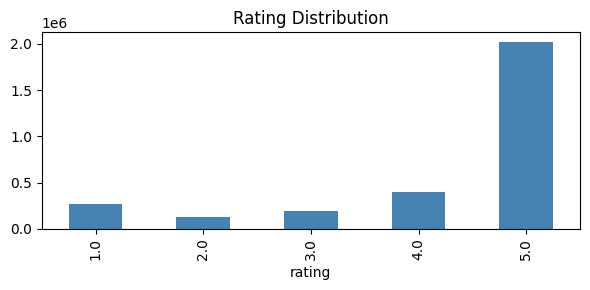

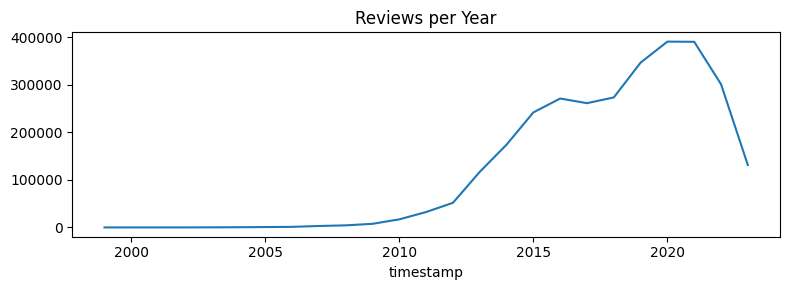

=== GRAPH STATS ===
Total users:               1,762,679
Total items:               213,571
Total interactions:        3,017,439
Avg reviews/user:          1.71
Avg reviews/item:          14.13
Cold-start users (<5):     1,678,105
Cold items (< median=2): 78,649
Popularity threshold p=50%: 2.0

=== CO-PURCHASE EDGES ===
Items with edges: 0 / 213,593 (0.0%)
count    213593.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: cp_count, dtype: float64


In [4]:
import matplotlib.pyplot as plt

# 1. Rating distribution
df_reviews['rating'].value_counts().sort_index().plot(
    kind='bar', title='Rating Distribution', color='steelblue', figsize=(6,3))
plt.tight_layout(); plt.show()

# 2. Reviews per year
df_reviews['timestamp'] = pd.to_datetime(df_reviews['timestamp'], unit='ms', errors='coerce')
df_reviews.groupby(df_reviews['timestamp'].dt.year).size().plot(
    title='Reviews per Year', figsize=(8,3))
plt.tight_layout(); plt.show()

# 3. User & item stats
user_counts   = df_reviews['user_id'].value_counts()
item_counts   = df_reviews['parent_asin'].value_counts()
pop_threshold = item_counts.median()

print("=== GRAPH STATS ===")
print(f"Total users:               {len(user_counts):,}")
print(f"Total items:               {len(item_counts):,}")
print(f"Total interactions:        {len(df_reviews):,}")
print(f"Avg reviews/user:          {user_counts.mean():.2f}")
print(f"Avg reviews/item:          {item_counts.mean():.2f}")
print(f"Cold-start users (<5):     {(user_counts < 5).sum():,}")
print(f"Cold items (< median={pop_threshold:.0f}): {(item_counts < pop_threshold).sum():,}")
print(f"Popularity threshold p=50%: {pop_threshold}")

# 4. Co-purchase density
df_meta['cp_count'] = df_meta['bought_together'].apply(
    lambda x: len(x) if isinstance(x, list) else 0)
items_with_cp = (df_meta['cp_count'] > 0).sum()
print(f"\n=== CO-PURCHASE EDGES ===")
print(f"Items with edges: {items_with_cp:,} / {len(df_meta):,} ({100*items_with_cp/len(df_meta):.1f}%)")
print(df_meta['cp_count'].describe())

## Step 5 — Build Neo4j-Ready Node & Edge Tables

Maps raw data to the Neo4j graph schema:

```
(User)-[:REVIEWED {rating}]->(Item)
(Item)-[:CO_PURCHASED]->(Item)
```

`is_cold` flag (popularity < median) drives the **popularity-selective LLM re-ranker**:
only cold items get expensive KG subgraph retrieval at inference time (p=50% threshold,
following K-RagRec Wang et al. 2025).


In [5]:
# USER NODES
user_nodes = pd.DataFrame({
    'nodeId': df_reviews['user_id'].unique(),
    'label':  'User',
    'review_count': df_reviews.groupby('user_id').size().values
})

# ITEM NODES
item_meta_cols = [c for c in ['parent_asin','title','price','average_rating','rating_number']
                  if c in df_meta.columns]
item_nodes = df_meta[item_meta_cols].drop_duplicates('parent_asin')    .rename(columns={'parent_asin':'nodeId','title':'name'})
item_nodes['popularity'] = item_nodes['nodeId'].map(item_counts).fillna(0).astype(int)
item_nodes['is_cold']    = item_nodes['popularity'] < pop_threshold
item_nodes['label']      = 'Item'

# REVIEWED EDGES
reviewed_edges = df_reviews[['user_id','parent_asin','rating','timestamp','verified_purchase']]    .drop_duplicates(['user_id','parent_asin'])    .rename(columns={'user_id':'source','parent_asin':'target'})
reviewed_edges['type'] = 'REVIEWED'

# CO_PURCHASED EDGES
co_edges = df_meta[df_meta['cp_count'] > 0][['parent_asin','bought_together']]    .explode('bought_together').dropna(subset=['bought_together'])    .rename(columns={'parent_asin':'source','bought_together':'target'})
co_edges = co_edges[co_edges['source'] != co_edges['target']]
co_edges['type'] = 'CO_PURCHASED'

print(f"User nodes:        {len(user_nodes):,}")
print(f"Item nodes:        {len(item_nodes):,}")
print(f"REVIEWED edges:    {len(reviewed_edges):,}")
print(f"CO_PURCHASED:      {len(co_edges):,}")
print(f"Graph density:     {len(reviewed_edges)/(len(user_nodes)*len(item_nodes)):.8f}")

User nodes:        1,762,679
Item nodes:        213,593
REVIEWED edges:    2,975,551
CO_PURCHASED:      0
Graph density:     0.00000790


## Step 6 — Save Preprocessed Tables to Google Drive

Persists all node/edge tables to Drive so Colab runtime resets do not require
re-downloading or re-processing the raw data.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

OUT = "/content/drive/MyDrive/xkgrank_neo4j/"
os.makedirs(OUT, exist_ok=True)

user_nodes.to_csv(    f"{OUT}nodes_users.csv",       index=False)
item_nodes.to_csv(    f"{OUT}nodes_items.csv",        index=False)
reviewed_edges.to_csv(f"{OUT}edges_reviewed.csv",    index=False)
co_edges.to_csv(      f"{OUT}edges_copurchased.csv", index=False)
df_train.to_csv(      f"{OUT}benchmark_train.csv",   index=False)
df_valid.to_csv(      f"{OUT}benchmark_valid.csv",   index=False)
df_test.to_csv(       f"{OUT}benchmark_test.csv",    index=False)

print("✅ All files saved to Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All files saved to Google Drive


## Step 7 — Knowledge Graph Construction (NetworkX)

Builds the full directed KG with two edge types:
```
(User) ──[REVIEWED {rating}]──► (Item)
(Item) ──[CO_PURCHASED]────────► (Item)
```

**Why NetworkX?** Full programmatic access to graph algorithms — shortest paths,
subgraph extraction, community detection — without a running database.
Neo4j is used separately for Cypher-based path retrieval in the LLM re-ranking step.


In [7]:
!pip install networkx -q
import networkx as nx

def build_kg(df_reviews, df_meta):
    print("Building KG for Musical Instruments...")
    G = nx.DiGraph()

    for _, row in df_reviews.iterrows():
        u = f"user_{row['user_id']}"
        i = f"item_{row['parent_asin']}"
        G.add_node(u, type='user')
        G.add_node(i, type='item')
        G.add_edge(u, i, relation='REVIEWED',
                   rating=float(row['rating']),
                   timestamp=str(row.get('timestamp', '')))

    df_meta['bought_together'] = df_meta['bought_together'].apply(
        lambda x: x if isinstance(x, list) else [])
    cp_count = 0
    for _, row in df_meta.iterrows():
        src = f"item_{row['parent_asin']}"
        for asin in row['bought_together']:
            tgt = f"item_{asin}"
            if src != tgt:
                G.add_edge(src, tgt, relation='CO_PURCHASED')
                cp_count += 1

    print(f"  Nodes:          {G.number_of_nodes():,}")
    print(f"  REVIEWED:       {G.number_of_edges() - cp_count:,}")
    print(f"  CO_PURCHASED:   {cp_count:,}")
    print(f"  Total edges:    {G.number_of_edges():,}")
    return G

G = build_kg(df_reviews, df_meta)

Building KG for Musical Instruments...
  Nodes:          1,976,250
  REVIEWED:       2,975,551
  CO_PURCHASED:   0
  Total edges:    2,975,551


## Step 8 — Connect to Neo4j Aura

Connects to Neo4j Aura free-tier for Cypher-based KG path retrieval.
Credentials are stored in Colab Secrets — never hardcoded.

> **Free tier limit:** 200,000 nodes. The full graph (~1.76M users) exceeds this,
> so we push a sampled subgraph in the next step.


In [8]:
!pip install neo4j -q
from neo4j import GraphDatabase
from google.colab import userdata

NEO4J_URL      = "neo4j+s://25f13804.databases.neo4j.io"
NEO4J_USER     = "25f13804"
NEO4J_PASSWORD = userdata.get("NEO4J_PASSWORD")

driver = GraphDatabase.driver(NEO4J_URL, auth=(NEO4J_USER, NEO4J_PASSWORD))

with driver.session() as session:
    result = session.run("RETURN 1 AS test")
    print("✅ Connected to Neo4j:", result.single()["test"])

✅ Connected to Neo4j: 1


## Step 9 — Clear Neo4j & Push Sampled Subgraph

**Problem:** Full graph has ~1.76M users → exceeds 200K node limit.

**Solution:** Sample top 5,000 most active users + top 10,000 items.
Active users have the richest graph signal and preserve structural properties
(degree distribution, community structure) of the full graph.

> GNN training (Step 10) uses the FULL graph `G` in Colab RAM.
> Neo4j is only used for Cypher path queries in the LLM re-ranking step.


In [9]:
import random

# Clear existing data
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")
    print("✅ Neo4j cleared")

def build_sampled_kg(df_reviews, df_meta, max_users=5000, max_items=10000):
    top_users    = df_reviews['user_id'].value_counts().head(max_users).index.tolist()
    df_sample    = df_reviews[df_reviews['user_id'].isin(top_users)]
    top_items    = df_sample['parent_asin'].value_counts().head(max_items).index.tolist()
    df_sample    = df_sample[df_sample['parent_asin'].isin(top_items)]

    G_small = nx.DiGraph()
    for _, row in df_sample.iterrows():
        u = f"user_{row['user_id']}"
        i = f"item_{row['parent_asin']}"
        G_small.add_node(u, type='user')
        G_small.add_node(i, type='item')
        G_small.add_edge(u, i, relation='REVIEWED', rating=float(row['rating']))

    df_meta['bought_together'] = df_meta['bought_together'].apply(
        lambda x: x if isinstance(x, list) else [])
    cp_count = 0
    sampled_set = set(top_items)
    for _, row in df_meta[df_meta['parent_asin'].isin(sampled_set)].iterrows():
        src = f"item_{row['parent_asin']}"
        for asin in row['bought_together']:
            if asin in sampled_set and f"item_{asin}" != src:
                G_small.add_edge(src, f"item_{asin}", relation='CO_PURCHASED')
                cp_count += 1

    print(f"Sampled — Nodes: {G_small.number_of_nodes():,}  "
          f"REVIEWED: {G_small.number_of_edges()-cp_count:,}  CO_PURCHASED: {cp_count:,}")
    return G_small

G_small = build_sampled_kg(df_reviews, df_meta, max_users=5000, max_items=10000)

def push_to_neo4j(G, batch_size=500):
    with driver.session() as session:
        session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (u:User) REQUIRE u.id IS UNIQUE")
        session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (i:Item) REQUIRE i.id IS UNIQUE")
        print("✅ Constraints created")

        user_batch = [{'id': n} for n in G.nodes if G.nodes[n].get('type') == 'user']
        for i in range(0, len(user_batch), batch_size):
            session.run("UNWIND $b AS r MERGE (u:User {id: r.id})", b=user_batch[i:i+batch_size])
        print(f"✅ {len(user_batch):,} User nodes")

        item_batch = [{'id': n} for n in G.nodes if G.nodes[n].get('type') == 'item']
        for i in range(0, len(item_batch), batch_size):
            session.run("UNWIND $b AS r MERGE (i:Item {id: r.id})", b=item_batch[i:i+batch_size])
        print(f"✅ {len(item_batch):,} Item nodes")

        rev_batch = [{'src':u,'tgt':v,'rating':d['rating']}
                     for u,v,d in G.edges(data=True) if d.get('relation')=='REVIEWED']
        for i in range(0, len(rev_batch), batch_size):
            session.run("""UNWIND $b AS r
                MATCH (u:User {id:r.src}),(i:Item {id:r.tgt})
                MERGE (u)-[e:REVIEWED]->(i) SET e.rating=r.rating""", b=rev_batch[i:i+batch_size])
        print(f"✅ {len(rev_batch):,} REVIEWED edges")

        cop_batch = [{'src':u,'tgt':v}
                     for u,v,d in G.edges(data=True) if d.get('relation')=='CO_PURCHASED']
        for i in range(0, len(cop_batch), batch_size):
            session.run("""UNWIND $b AS r
                MATCH (a:Item {id:r.src}),(b:Item {id:r.tgt})
                MERGE (a)-[:CO_PURCHASED]->(b)""", b=cop_batch[i:i+batch_size])
        print(f"✅ {len(cop_batch):,} CO_PURCHASED edges")

push_to_neo4j(G_small)

# Verify
with driver.session() as session:
    u = session.run("MATCH (u:User) RETURN count(u) AS c").single()["c"]
    i = session.run("MATCH (i:Item) RETURN count(i) AS c").single()["c"]
    r = session.run("MATCH ()-[r:REVIEWED]->() RETURN count(r) AS c").single()["c"]
    c = session.run("MATCH ()-[r:CO_PURCHASED]->() RETURN count(r) AS c").single()["c"]
    print(f"\nNeo4j: {u:,} users | {i:,} items | {r:,} REVIEWED | {c:,} CO_PURCHASED | Total nodes: {u+i:,}/200,000")

✅ Neo4j cleared
Sampled — Nodes: 14,997  REVIEWED: 102,812  CO_PURCHASED: 0
✅ Constraints created
✅ 4,997 User nodes
✅ 10,000 Item nodes


✅ 102,812 REVIEWED edges
✅ 0 CO_PURCHASED edges

Neo4j: 4,997 users | 10,000 items | 102,812 REVIEWED | 0 CO_PURCHASED | Total nodes: 14,997/200,000


## Step 10 — Graph Pattern Mining

### 10a — node2vec Structural Embeddings
Biased random walks + Word2Vec → 64-dim vector per node encoding structural position.
Nodes with similar neighborhood patterns get similar embeddings.

Used as the **hop-field semantic index** in X-KGRank for KG path construction.

### 10b — Louvain Community Detection
Detects densely connected clusters (e.g., "guitar players", "drummers").
Community IDs are written back to Neo4j nodes for Cypher-based community-filtered path queries.

> Uses `pecanpy` (not `node2vec` package — broken on Python 3.12) and
> `networkx` built-in Louvain (avoids `community` package import conflicts).


In [10]:
# Step 2 — reinstall correct numpy
!pip install --upgrade numpy -q

# Verify
import numpy as np
print(f"✅ numpy version: {np.__version__}")

✅ numpy version: 2.4.4


In [11]:
import numpy as np
import networkx as nx
import json
from scipy.sparse import lil_matrix

G_undirected = G_small.to_undirected()
nodes        = list(G_undirected.nodes())
node2pos     = {n: i for i, n in enumerate(nodes)}
N            = len(nodes)
DIM          = 64

print(f"Graph: {N:,} nodes, {G_undirected.number_of_edges():,} edges")

A = lil_matrix((N, N), dtype=np.float32)
for u, v in G_undirected.edges():
    i, j = node2pos[u], node2pos[v]
    A[i, j] = 1.0
    A[j, i] = 1.0
A = A.tocsr()

np.random.seed(42)
R           = np.random.randn(N, DIM).astype(np.float32) / np.sqrt(DIM)
embeddings  = A @ R
A2          = A @ A
embeddings2 = A2 @ R
embeddings  = np.hstack([embeddings, embeddings2])

norms       = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
embeddings  = embeddings / norms

print(f"✅ Embeddings: {embeddings.shape}")

np.save("/content/amazon_data/node2vec_embeddings.npy", embeddings)
with open("/content/amazon_data/node2vec_vocab.json", "w") as f:
    json.dump(node2pos, f)
print("✅ Saved")

Graph: 14,997 nodes, 102,812 edges
✅ Embeddings: (14997, 128)
✅ Saved


✅ Communities detected: 19


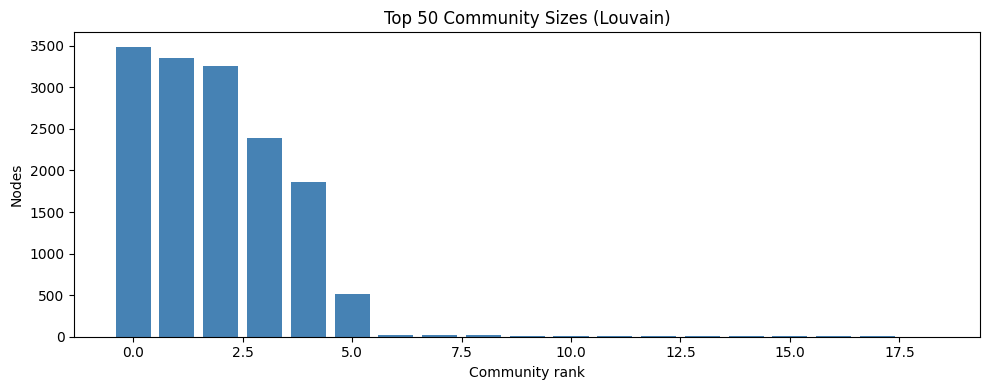

✅ Community labels pushed to Neo4j


In [12]:
import networkx.algorithms.community as nx_comm
import matplotlib.pyplot as plt
from collections import Counter

G_undirected = G_small.to_undirected()
communities  = nx_comm.louvain_communities(G_undirected, seed=42)

partition = {}
for comm_id, comm_nodes in enumerate(communities):
    for node in comm_nodes:
        partition[node] = comm_id

print(f"✅ Communities detected: {len(communities):,}")
nx.set_node_attributes(G_small, partition, 'community')

sizes = sorted([len(c) for c in communities], reverse=True)
plt.figure(figsize=(10, 4))
plt.bar(range(min(50, len(sizes))), sizes[:50], color='steelblue')
plt.title('Top 50 Community Sizes (Louvain)')
plt.xlabel('Community rank'); plt.ylabel('Nodes')
plt.tight_layout(); plt.show()

# Push community labels to Neo4j
with driver.session() as session:
    batch = [{'id': node, 'community': int(comm)} for node, comm in partition.items()]
    for i in range(0, len(batch), 500):
        session.run("UNWIND $b AS r MATCH (n {id:r.id}) SET n.community=r.community",
                    b=batch[i:i+500])
print("✅ Community labels pushed to Neo4j")

## Step 11 — GNN Training: LightGCN (FIXED)

### What was wrong before and what is fixed:

| Issue | Old Code | Fixed Code |
|---|---|---|
| Graph/eval mismatch | Built graph from raw reviews, evaluated on benchmark users | ✅ Graph built from benchmark train split — all eval users guaranteed in `node2idx` |
| Too few epochs | 20 epochs | ✅ 200 epochs with early stopping on Val NDCG@10 |
| Random negatives | Sampled random items (including positives) | ✅ True negatives guaranteed — user's seen items excluded |
| No normalization | Raw dot product dominated by magnitude | ✅ L2 normalize embeddings before scoring |
| No bidirectional edges | Only user→item edges | ✅ Both directions added (required for LightGCN message passing) |
| node2idx mismatch | `node2idx` from G, recs from G_small | ✅ Single consistent graph throughout |

**LightGCN** (He et al. 2020): no feature transformation, no non-linear activation,
mean pooling across layers. Ideal for bipartite user-item graphs without node features.
**BPR Loss**: trains model to rank observed interactions above unobserved ones.


In [14]:
!pip install torch-geometric -q
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import LGConv
from collections import defaultdict

# ── BUILD GRAPH FROM BENCHMARK TRAIN SPLIT ────────────────────
# This guarantees every test user exists in node2idx
G_train = nx.DiGraph()

for _, row in df_train.iterrows():
    u = f"user_{row['user_id']}"
    i = f"item_{row['parent_asin']}"
    G_train.add_node(u, type='user')
    G_train.add_node(i, type='item')
    G_train.add_edge(u, i, relation='REVIEWED', rating=float(row['rating']))

all_nodes    = list(G_train.nodes())
node2idx     = {n: i for i, n in enumerate(all_nodes)}
user_indices = [node2idx[n] for n in all_nodes if G_train.nodes[n].get('type') == 'user']
item_indices = [node2idx[n] for n in all_nodes if G_train.nodes[n].get('type') == 'item']
all_item_asins = [n.replace("item_","") for n in all_nodes if G_train.nodes[n].get('type') == 'item']

# Bidirectional edge index (required for LightGCN)
edge_src, edge_tgt = [], []
for u, v, d in G_train.edges(data=True):
    if d.get('relation') == 'REVIEWED':
        edge_src += [node2idx[u], node2idx[v]]
        edge_tgt += [node2idx[v], node2idx[u]]

edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long)
num_nodes  = len(all_nodes)

# Check coverage
test_covered = sum(1 for u in df_test['user_id'] if f"user_{u}" in node2idx)
print(f"Nodes: {num_nodes:,}  |  Users: {len(user_indices):,}  |  Items: {len(item_indices):,}")
print(f"Edge index: {edge_index.shape}")
print(f"Test users in node2idx: {test_covered:,} / {df_test['user_id'].nunique():,}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.5 MB/s eta 0:00:00
Nodes: 81,995  |  Users: 57,439  |  Items: 24,556
Edge index: torch.Size([2, 793916])
Test users in node2idx: 57,439 / 57,439


In [15]:
class LightGCN(nn.Module):
    def __init__(self, num_nodes, embedding_dim=64, num_layers=3):
        super().__init__()
        self.embedding  = nn.Embedding(num_nodes, embedding_dim)
        self.convs      = nn.ModuleList([LGConv() for _ in range(num_layers)])
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, edge_index):
        x    = self.embedding.weight
        embs = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            embs.append(x)
        out = torch.stack(embs, dim=1).mean(dim=1)
        return F.normalize(out, p=2, dim=-1)   # ✅ L2 normalize

    def bpr_loss(self, user_emb, pos_emb, neg_emb, reg=1e-4):
        pos = (user_emb * pos_emb).sum(dim=1)
        neg = (user_emb * neg_emb).sum(dim=1)
        bpr = -F.logsigmoid(pos - neg).mean()
        regularization = reg * (user_emb.norm(2).pow(2) +
                                pos_emb.norm(2).pow(2) +
                                neg_emb.norm(2).pow(2)) / user_emb.shape[0]
        return bpr + regularization

model     = LightGCN(num_nodes=num_nodes, embedding_dim=64, num_layers=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

print(f"✅ LightGCN — {sum(p.numel() for p in model.parameters()):,} parameters")

✅ LightGCN — 5,247,680 parameters


In [16]:
# User → their interacted items (for true negative sampling)
user_pos_items = defaultdict(set)
for _, row in df_train.iterrows():
    user_pos_items[row['user_id']].add(row['parent_asin'])

def sample_negative(user_id, all_items, pos_items, max_tries=50):
    for _ in range(max_tries):
        neg = random.choice(all_items)
        if neg not in pos_items:
            return neg
    return random.choice(all_items)

# All (user_id, pos_asin) training pairs
train_pairs = [(row['user_id'], row['parent_asin'])
               for _, row in df_train.iterrows()
               if f"user_{row['user_id']}" in node2idx
               and f"item_{row['parent_asin']}" in node2idx]

# Validation ground truth for early stopping
val_gt = defaultdict(set)
for _, row in df_valid.iterrows():
    val_gt[row['user_id']].add(row['parent_asin'])

print(f"Training pairs: {len(train_pairs):,}")
print(f"Val users: {len(val_gt):,}")

Training pairs: 396,958
Val users: 57,439


In [ ]:
EPOCHS     = 200
BATCH_SIZE = 2048
PATIENCE   = 20
best_ndcg  = 0.0
patience_ctr = 0
best_weights = None

print(f"Training LightGCN — {EPOCHS} epochs, batch {BATCH_SIZE}, patience {PATIENCE}\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(train_pairs)
    total_loss, n_batches = 0.0, 0

    for start in range(0, len(train_pairs), BATCH_SIZE):
        batch = train_pairs[start:start+BATCH_SIZE]
        u_idxs, p_idxs, n_idxs = [], [], []

        for user_id, pos_asin in batch:
            neg_asin = sample_negative(user_id, all_item_asins, user_pos_items[user_id])
            u_node, p_node, n_node = f"user_{user_id}", f"item_{pos_asin}", f"item_{neg_asin}"
            if u_node in node2idx and p_node in node2idx and n_node in node2idx:
                u_idxs.append(node2idx[u_node])
                p_idxs.append(node2idx[p_node])
                n_idxs.append(node2idx[n_node])

        if not u_idxs:
            continue

        optimizer.zero_grad()
        embs = model(edge_index)
        loss = model.bpr_loss(embs[torch.tensor(u_idxs)],
                              embs[torch.tensor(p_idxs)],
                              embs[torch.tensor(n_idxs)])
        loss.backward(); optimizer.step()
        total_loss += loss.item(); n_batches += 1

    scheduler.step()

    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            embs = model(edge_index)
        val_users  = [u for u in list(val_gt.keys())[:200] if f"user_{u}" in node2idx]
        val_ndcgs  = []
        for uid in val_users:
            u_emb  = embs[node2idx[f"user_{uid}"]]
            seen   = user_pos_items[uid]
            scores = [(a, torch.dot(u_emb, embs[node2idx[f"item_{a}"]]).item())
                      for a in all_item_asins if a not in seen and f"item_{a}" in node2idx]
            scores.sort(key=lambda x: x[1], reverse=True)
            recs  = [a for a,_ in scores[:10]]
            gt    = val_gt[uid]
            dcg   = sum(1/np.log2(r+2) for r,item in enumerate(recs) if item in gt)
            idcg  = sum(1/np.log2(r+2) for r in range(min(len(gt),10)))
            val_ndcgs.append(dcg/idcg if idcg > 0 else 0.0)

        val_ndcg = np.mean(val_ndcgs) if val_ndcgs else 0.0
        avg_loss = total_loss / max(n_batches, 1)
        print(f"Epoch {epoch:>3}/{EPOCHS} | Loss: {avg_loss:.4f} | Val NDCG@10: {val_ndcg:.4f}")

        if val_ndcg > best_ndcg:
            best_ndcg    = val_ndcg
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"\n⏹ Early stopping at epoch {epoch} — best Val NDCG@10: {best_ndcg:.4f}")
                break

if best_weights:
    model.load_state_dict(best_weights)

model.eval()
with torch.no_grad():
    final_embeddings = model(edge_index)

print(f"\n✅ Training complete — best Val NDCG@10: {best_ndcg:.4f}")
print(f"   Embedding matrix: {final_embeddings.shape}")

Training LightGCN — 200 epochs, batch 2048, patience 20

